## Unsupervised Learning of Digit Recognition Using STDP 

In [1]:
!pip install myst-nb


[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import zipfile
import json
import itertools
import random
from myst_nb import glue

random.seed(0)

def dataGenerator(path):
    with zipfile.ZipFile(path) as train_zip:
        with train_zip.open('index.json') as index_file:
            idx_info = json.loads(index_file.read())
            files = idx_info['files']
            N = idx_info['N']
            i = 0
            
            for fname in files:
                with train_zip.open(fname) as f:
                    data = json.loads(f.read())
                    images = data['images']
                    labels = data['labels']
                    for img, label in zip(images, labels):
                        yield (img, label)
                        i += 1
                        if i >= N: break          

DIGIT_WIDTH  = 14
DIGIT_HEIGHT = 14
DIGIT_SIZE   = DIGIT_WIDTH * DIGIT_HEIGHT
glue("DIGIT_SIZE", DIGIT_SIZE, display=False)
glue("DIGIT_WIDTH", DIGIT_WIDTH, display=False)
glue("DIGIT_HEIGHT", DIGIT_HEIGHT, display=False)

# trainDataGenerator = dataGenerator('./train-chunked.zip')
trainDataGenerator = dataGenerator('./train-14x14-chunked.zip')

In [3]:
randomImage, randomLabel = random.choice(list(itertools.islice(trainDataGenerator, 0, 100)))
print(randomImage)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 5, 57, 125, 209, 214, 175, 66, 19, 0, 0, 0, 23, 1, 0, 51, 220, 250, 245, 228, 249, 239, 108, 0, 0, 0, 20, 1, 0, 12, 98, 138, 160, 217, 245, 189, 33, 0, 0, 0, 0, 0, 0, 4, 62, 187, 247, 227, 134, 37, 0, 0, 0, 0, 0, 0, 0, 27, 222, 253, 212, 38, 2, 0, 0, 0, 0, 0, 0, 0, 0, 2, 42, 78, 216, 209, 53, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 27, 163, 189, 16, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 113, 208, 28, 0, 0, 0, 0, 0, 39, 174, 84, 37, 106, 146, 229, 155, 11, 0, 0, 0, 0, 0, 62, 230, 220, 219, 246, 223, 152, 32, 0, 0, 0, 0, 0, 0, 3, 114, 211, 153, 86, 32, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


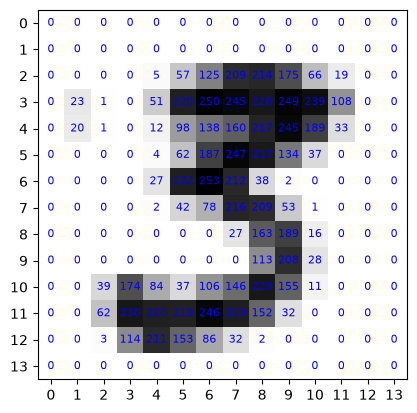

Label: 3


In [4]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(0)
digitPixels = np.reshape(np.array(randomImage), (DIGIT_WIDTH, DIGIT_HEIGHT))


plt.figure()
plt.imshow(digitPixels, cmap='gray_r')
plt.axis('on')
for i in range(digitPixels.shape[0]):
    for j in range(digitPixels.shape[1]):
        plt.text(j, i, int(digitPixels[i, j]), color='blue', fontsize=8, ha='center', va='center')

# Setting the ticks to show every number on both axes
plt.xticks(np.arange(0, DIGIT_WIDTH, 1))
plt.yticks(np.arange(0, DIGIT_HEIGHT, 1))

plt.show()

print('Label:', randomLabel)

In [5]:
import numpy as np

def poisson_fire(values, min_value=0, max_value=255, min_rate=0, max_rate=10, dt=0.001):
    relativeValues = (values - min_value) / (max_value - min_value)
    relativeRates = min_rate + relativeValues * (max_rate - min_rate)
    probsOfFire = relativeRates * dt

    firings = np.random.rand(*values.shape) < probsOfFire
    return firings / dt

In [6]:
class SynapseCollection:
    def __init__(self, n=1, tau_s=0.05, t_step=0.001):
        self.n = n
        self.a = np.exp(-t_step / tau_s)  # Decay factor for synaptic current
        self.b = 1 - self.a  # Scale factor for input current

        self.voltage = np.zeros(n)  # Initial voltage of neurons
    
    def step(self, inputs):
        self.voltage = self.a * self.voltage + self.b * inputs

        return self.voltage

In [7]:
t_step = 0.001
synapses = SynapseCollection(n=len(randomImage), tau_s=0.1, t_step=t_step)

def step1(inp):
    input_spikes = poisson_fire(np.array(inp), dt=t_step, min_rate=0.1, max_rate=100)
    return input_spikes, synapses.step(input_spikes)

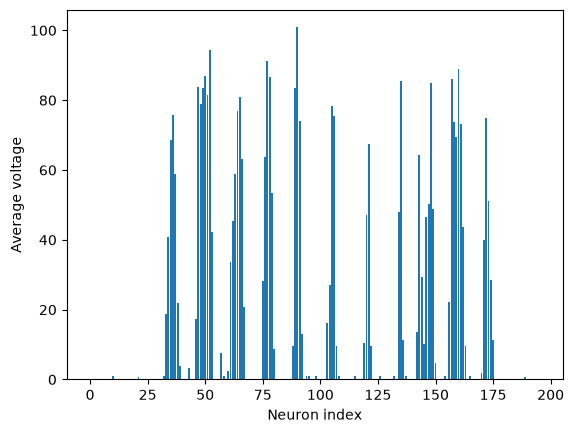

In [8]:
import matplotlib.pyplot as plt

voltages_over_time = []
T = 1 # second
for _ in np.arange(0, T, t_step):
    spikes, psp_voltages = step1(randomImage)
    voltages_over_time.append(psp_voltages)

average_values = np.mean(voltages_over_time, axis=0)

plt.figure()
# plt.bar(average_values)
plt.bar(np.arange(len(average_values)), average_values)
plt.xlabel('Neuron index')
plt.ylabel('Average voltage')
plt.show()

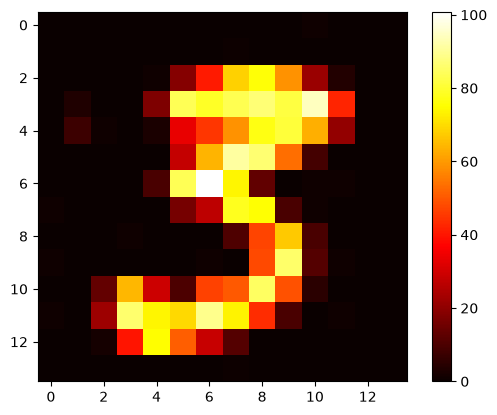

In [9]:
# plot in a 14x14 grid
plt.figure()
plt.imshow(average_values.reshape(14, 14), cmap='hot')
plt.colorbar()
plt.show()

In [10]:
TIME_TO_SHOW_IMAGES = 0.35 # seconds
TIME_TO_SHOW_BLANK  = 0.15 # seconds

In [11]:
NUM_IMAGES = 100

for _ in range(NUM_IMAGES):
    current_image, label = next(trainDataGenerator)

    for _ in np.arange(0, TIME_TO_SHOW_IMAGES, t_step):
        step1(np.array(current_image))
    for _ in np.arange(0, TIME_TO_SHOW_BLANK, t_step):
        step1(np.zeros(len(current_image)))

In [12]:
class STDPWeights:
    def __init__(self, numPre, numPost, tau_plus = 0.03, tau_minus = 0.03, a_plus = 0.1, a_minus = 0.11, g_min=0, g_max=1):
        self.numPre = numPre
        self.numPost = numPost
        self.tau_plus = tau_plus
        self.tau_minus = tau_minus
        self.a_plus = a_plus
        self.a_minus = a_minus
        self.x = np.zeros(numPre)
        self.y = np.zeros(numPost)

        self.g_min = g_min
        self.g_max = g_max
        self.w = np.random.uniform(g_min, g_max, (numPre, numPost)) / numPost # Initialize weights


    def step(self, t_step):
        self.x = self.x * np.exp(-t_step/self.tau_plus)
        self.y = self.y * np.exp(-t_step/self.tau_minus)

    def updateWeights(self, preOutputs, postOutputs):
        self.x += (preOutputs  > 0) * self.a_plus
        self.y -= (postOutputs > 0) * self.a_minus

        alpha_g = self.g_max - self.g_min # Scaling factor for weight updates

        preSpikeIndices = np.where(preOutputs > 0)[0]   # Indices of pre-synaptic   spiking neurons
        postSpikeIndices = np.where(postOutputs > 0)[0]

        for ps_idx in preSpikeIndices:
            self.w[ps_idx] += alpha_g * self.y
            self.w[ps_idx] = np.clip(self.w[ps_idx], self.g_min, self.g_max)

        for ps_idx in postSpikeIndices:
            self.w[:, ps_idx] += alpha_g * self.x
            self.w[:, ps_idx] = np.clip(self.w[:, ps_idx], self.g_min, self.g_max)

class LIF:
    def __init__(self, n=1, dim=1, tau_rc=0.02, tau_ref=0.002, v_th=1, 
                 max_rates=[200, 400], intercept_range=[-1, 1], t_step=0.001, v_init = 0):
        self.n = n
        # Set neuron parameters
        self.dim = dim  # Dimensionality of the input
        self.tau_rc = tau_rc  # Membrane time constant
        self.tau_ref = tau_ref  # Refractory period
        self.v_th = np.ones(n) * v_th  # Threshold voltage for spiking
        self.t_step = t_step  # Time step for simulation
        
        # Initialize state variables
        # self.voltage = np.ones(n) * v_init  # Initial voltage of neurons
        self.voltage = np.random.uniform(0, 1, n)  # Initial voltage of neurons
        self.refractory_time = np.zeros(n)  # Time remaining in refractory period
        self.output = np.zeros(n)  # Output spikes

        # Generate random max rates and intercepts within the given range
        max_rates_tensor = np.random.uniform(max_rates[0], max_rates[1], n)
        intercepts_tensor = np.random.uniform(intercept_range[0], intercept_range[1], n)

        # Calculate gain and bias for each neuron
        # self.gain = self.v_th * (1 - 1 / (1 - np.exp((self.tau_ref - 1/max_rates_tensor) / self.tau_rc))) / (intercepts_tensor - 1)
        # self.bias = np.expand_dims(self.v_th - self.gain * intercepts_tensor, axis=1)
        self.gain = np.ones(n)
        self.bias = np.zeros(n)
        
        # Initialize random encoders
        # self.encoders = np.random.randn(n, self.dim)
        # self.encoders /= np.linalg.norm(self.encoders, axis=1)[:, np.newaxis]
        self.encoders = np.ones((n, self.dim))

    def reset(self):
        # Reset the state variables to initial conditions
        self.voltage = np.zeros(self.n)
        self.refractory_time = np.zeros(self.n)
        self.output = np.zeros(self.n)

    def step(self, inputs):
        dt = self.t_step  # Time step

        # Update refractory time
        self.refractory_time -= dt
        delta_t = np.clip(dt - self.refractory_time, 0, dt) # ensure between 0 and dt

        # Calculate input current
        I = np.sum(self.bias + inputs * self.encoders * self.gain[:, np.newaxis], axis=0) / self.n

        # Update membrane potential
        self.voltage = I + (self.voltage - I) * np.exp(-delta_t / self.tau_rc)

        # Determine which neurons spike
        spike_mask = self.voltage > self.v_th
        self.output[:] = spike_mask / dt  # Record spikes in output

        # Calculate the time of the spike
        t_spike = self.tau_rc * np.log((self.voltage[spike_mask] - I[spike_mask]) / (self.v_th[spike_mask] - I[spike_mask])) + dt

        # Reset voltage of spiking neurons
        self.voltage[spike_mask] = 0

        # Set refractory time for spiking neurons
        self.refractory_time[spike_mask] = self.tau_ref + t_spike

        return self.output  # Return the output spikes

class ALIF:
    def __init__(self, n=1, dim=1, tau_rc=0.02, tau_ref=0.002, v_th=1, 
                 max_rates=[200, 400], intercept_range=[-1, 1], t_step=0.001, v_init = 0,
                 tau_inh=0.05, inc_inh=1.0 # <--- ADDED
                 ):
        self.n = n
        # Set neuron parameters
        self.dim = dim  # Dimensionality of the input
        self.tau_rc = tau_rc  # Membrane time constant
        self.tau_ref = tau_ref  # Refractory period
        self.v_th = np.ones(n) * v_th  # Threshold voltage for spiking
        self.t_step = t_step  # Time step for simulation

        self.inh = np.zeros(n)  # <--- ADDED
        self.tau_inh = tau_inh  # <--- ADDED
        self.inc_inh = inc_inh  # <--- ADDED
        
        # Initialize state variables
        # self.voltage = np.ones(n) * v_init  # Initial voltage of neurons
        self.voltage = np.random.uniform(0, 1, n)  # Initial voltage of neurons
        self.refractory_time = np.zeros(n)  # Time remaining in refractory period
        self.output = np.zeros(n)  # Output spikes

        # Generate random max rates and intercepts within the given range
        max_rates_tensor = np.random.uniform(max_rates[0], max_rates[1], n)
        intercepts_tensor = np.random.uniform(intercept_range[0], intercept_range[1], n)

        # Calculate gain and bias for each neuron
        # self.gain = self.v_th * (1 - 1 / (1 - np.exp((self.tau_ref - 1/max_rates_tensor) / self.tau_rc))) / (intercepts_tensor - 1)
        # self.bias = np.expand_dims(self.v_th - self.gain * intercepts_tensor, axis=1)
        self.gain = np.ones(n)
        self.bias = np.zeros(n)
        
        # Initialize random encoders
        # self.encoders = np.random.randn(n, self.dim)
        # self.encoders /= np.linalg.norm(self.encoders, axis=1)[:, np.newaxis]
        self.encoders = np.ones((n, self.dim))

    def reset(self):
        # Reset the state variables to initial conditions
        self.voltage = np.zeros(self.n)
        self.refractory_time = np.zeros(self.n)
        self.output = np.zeros(self.n)
        self.inh = np.zeros(self.n)  # <--- ADDED

    def step(self, inputs):
        dt = self.t_step  # Time step

        # Update refractory time
        self.refractory_time -= dt
        delta_t = np.clip(dt - self.refractory_time, 0, dt) # ensure between 0 and dt

        # Calculate input current
        I = np.sum(self.bias + inputs * self.encoders * self.gain[:, np.newaxis], axis=0) / self.n

        # Update membrane potential
        self.voltage = I + (self.voltage - I) * np.exp(-delta_t / self.tau_rc)

        # Determine which neurons spike
        spike_mask = self.voltage > self.v_th + self.inh  # <--- ADDED + self.inh
        self.output[:] = spike_mask / dt  # Record spikes in output

        # Calculate the time of the spike
        t_spike = self.tau_rc * np.log((self.voltage[spike_mask] - I[spike_mask]) / (self.v_th[spike_mask] - I[spike_mask])) + dt

        # Reset voltage of spiking neurons
        self.voltage[spike_mask] = 0

        # Set refractory time for spiking neurons
        self.refractory_time[spike_mask] = self.tau_ref + t_spike

        self.inh = self.inh * np.exp(-dt / self.tau_inh) + self.inc_inh * (self.output > 0)  # <--- ADDED

        return self.output  # Return the output spikes

In [13]:
NUM_EXCITATORY = 16

In [14]:
stdp = STDPWeights(numPre=DIGIT_SIZE, numPost=NUM_EXCITATORY)
excitatory_neurons = ALIF(n=NUM_EXCITATORY, t_step=t_step)
excitatory_psp     = SynapseCollection(n=NUM_EXCITATORY, t_step=t_step, tau_s=0.2)

def step2(inp):
    input_spikes = poisson_fire(np.array(inp), dt=t_step, min_rate=0.1, max_rate=100)
    excitatory_inp = synapses.step(input_spikes)

    stdp.step(t_step)
    stdp.updateWeights(input_spikes, excitatory_neurons.output)

    excitatory_inp = inp @ stdp.w
    excitatory_spikes = excitatory_neurons.step(excitatory_inp)
    excitatory_outp = excitatory_psp.step(excitatory_spikes)


step2(randomImage)

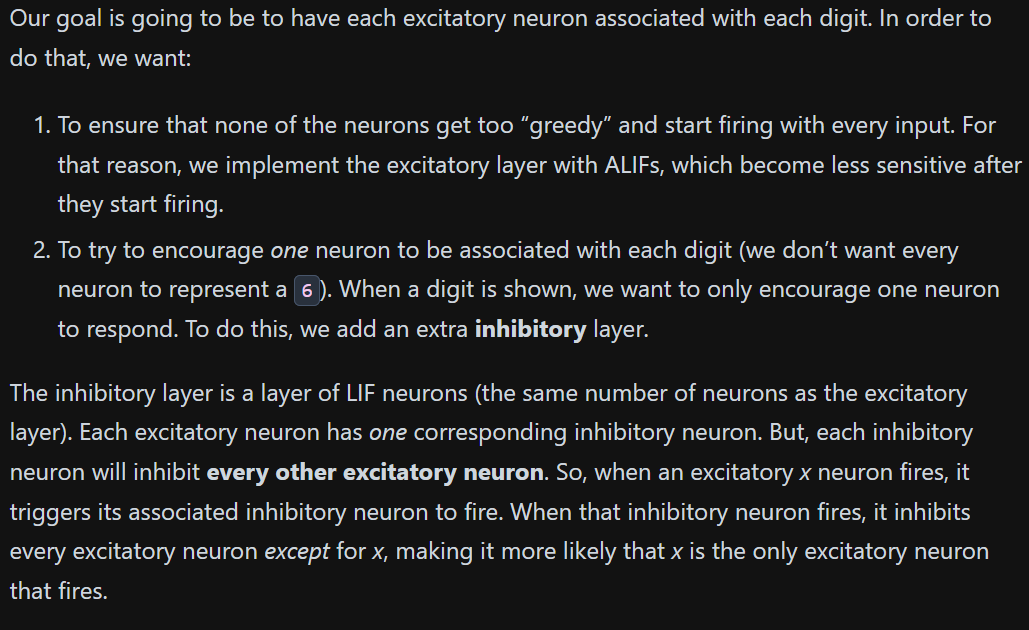

In [15]:
inhibitory_neurons = LIF(n=NUM_EXCITATORY, t_step=t_step)
inhibitory_psp     = SynapseCollection(n=NUM_EXCITATORY, t_step=t_step, tau_s=0.2)
inhibitory_outp    = np.zeros(NUM_EXCITATORY)

def step3(inp):
    global inhibitory_outp
    input_spikes = poisson_fire(np.array(inp), dt=t_step, min_rate=0.1, max_rate=100)
    excitatory_inp = synapses.step(input_spikes)

    stdp.step(t_step)
    stdp.updateWeights(input_spikes, excitatory_neurons.output)

    excitatory_inp = excitatory_inp @ stdp.w + inhibitory_outp * -1
    excitatory_spikes = excitatory_neurons.step(excitatory_inp)
    excitatory_outp = excitatory_psp.step(excitatory_spikes)

    inhibitory_spikes = inhibitory_neurons.step(excitatory_outp)
    raw_inhibitory_outp   = inhibitory_psp.step(inhibitory_spikes)
    total_inhibiry_outp = np.sum(raw_inhibitory_outp)
    inhibitory_outp = total_inhibiry_outp * np.ones(NUM_EXCITATORY) - raw_inhibitory_outp

step3(randomImage)

In [16]:
t_step = 0.002  # Time step for the simulation
synapses = SynapseCollection(n=DIGIT_SIZE, tau_s=0.1, t_step=t_step)  # Synapse collection for input connections

# STDP (Spike-Timing-Dependent Plasticity) weight matrix between input and excitatory neurons
stdp = STDPWeights(numPre=DIGIT_SIZE, numPost=NUM_EXCITATORY, g_min=-0.1, g_max=1.1)

# Inhibitory neurons and their corresponding post-synaptic potential (PSP) collection
inhibitory_neurons = LIF(n=NUM_EXCITATORY, t_step=t_step)
inhibitory_psp = SynapseCollection(n=NUM_EXCITATORY, t_step=t_step, tau_s=0.5)
inhibitory_outp = np.zeros(NUM_EXCITATORY)  # Initialize inhibitory output array

# Excitatory neurons and their corresponding PSP collection
excitatory_neurons = ALIF(n=NUM_EXCITATORY, t_step=t_step, tau_inh=1.1)
excitatory_psp = SynapseCollection(n=NUM_EXCITATORY, t_step=t_step, tau_s=0.2)

# Function to perform a simulation step
def step(inp, max_input_rate):
    global inhibitory_outp
    input_spikes = poisson_fire(np.array(inp), dt=t_step, min_rate=0.01, max_rate=max_input_rate)  # Generate input spikes
    input_psp = synapses.step(input_spikes)  # Step the input synapses to get PSP

    stdp.step(t_step)  # Step the STDP mechanism
    stdp.updateWeights(input_spikes, excitatory_neurons.output)  # Update weights based on input and output spikes

    excitatory_inp = input_psp @ stdp.w + np.clip(inhibitory_outp * -1, a_max=0, a_min=None)  # Calculate excitatory input combining synapse output and inhibitory output
    excitatory_spikes = excitatory_neurons.step(excitatory_inp)  # Step excitatory neurons to get their spikes

    excitatory_outp = excitatory_psp.step(excitatory_spikes)  # Update the excitatory post-synaptic potential

    inhibitory_spikes = inhibitory_neurons.step(excitatory_outp)  # Step inhibitory neurons using excitatory output
    # print(input_psp@stdp.w, excitatory_inp, excitatory_spikes, excitatory_outp, inhibitory_spikes)
    raw_inhibitory_outp = inhibitory_psp.step(inhibitory_spikes)  # Update the inhibitory post-synaptic potential
    total_inhibitory_outp = np.sum(raw_inhibitory_outp)  # Calculate the total inhibitory output
    inhibitory_outp = total_inhibitory_outp * np.ones(NUM_EXCITATORY) - raw_inhibitory_outp  # Calculate the inhibitory output for each neuron

    num_fires = np.sum(excitatory_spikes > 0)  # Count the number of excitatory neurons that fired
    return num_fires

def run_simulation(num_images=1):
    for _ in range(num_images):
        current_image, label = next(trainDataGenerator)  # Get the next image and label from the data generator

        total_fires = 0  # Initialize the total number of fires
        max_input_rate = 0.5  # Initial maximum input firing rate

        while total_fires < 5:
            for _ in np.arange(0, TIME_TO_SHOW_IMAGES, t_step):  # Display the image for a set duration
                num_fires = step(np.array(current_image), max_input_rate=max_input_rate)  # Perform a simulation step
                total_fires += num_fires  # Accumulate the number of fires
                if total_fires >= 5: break  # Break if the total number of fires is reached (this is different from the original paper but helps run the simulation faster)
            max_input_rate *= 1.1  # Increase the input firing rate

        for _ in np.arange(0, TIME_TO_SHOW_BLANK, t_step):  # Show a blank input for a set duration
            step(np.zeros(len(current_image)), max_input_rate=max_input_rate)  # Perform a simulation step with blank input

def plotWeights():
    NUM_DISPLAY_ROWS = 4
    NUM_DISPLAY_COLS = 4

    plt.figure()

    for i in range(NUM_EXCITATORY):
        plt.subplot(NUM_DISPLAY_ROWS, NUM_DISPLAY_COLS, i+1)
        plt.imshow(stdp.w[:, i].reshape(DIGIT_WIDTH, DIGIT_HEIGHT), cmap='gray')
        plt.axis('off')
    plt.show()

Randomly initialized weights


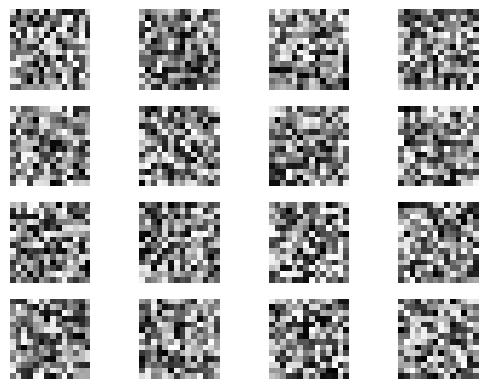

Run simulation for 100 images


C:\Users\skarki\AppData\Local\Temp\ipykernel_14180\2666458793.py:167: RuntimeWarning: invalid value encountered in log
  t_spike = self.tau_rc * np.log((self.voltage[spike_mask] - I[spike_mask]) / (self.v_th[spike_mask] - I[spike_mask])) + dt


Updated weights


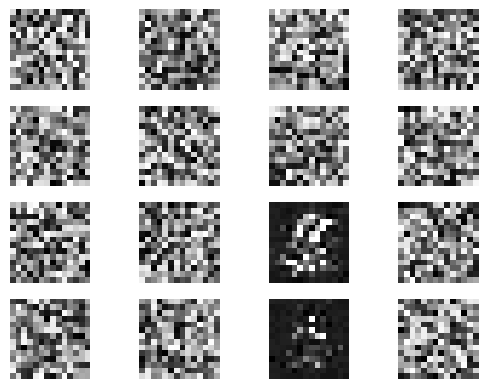

Run simulation for 1000 images
Updated weights


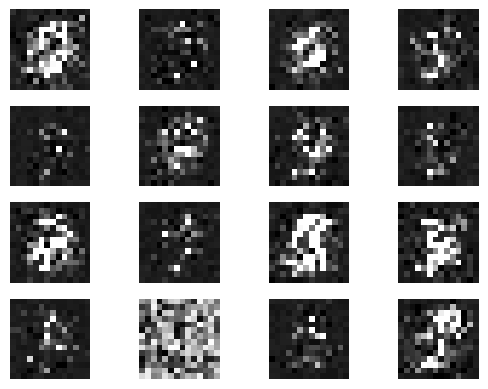

In [17]:
print("Randomly initialized weights"); plotWeights()

for n in [100, 1000]:
    print(f"Run simulation for {n} images"); run_simulation(num_images=n); print("Updated weights"); plotWeights()

In [18]:
from myst_nb import glue
import numpy as np

np.random.seed(0)

NUM_NEURONS = 400
NUM_NEURON_COLS = 20
NUM_NEURON_ROWS = 20

DIGIT_WIDTH =28
DIGIT_HEIGHT=28
DIGIT_SIZE=DIGIT_WIDTH*DIGIT_HEIGHT

glue("NUM_NEURONS", NUM_NEURONS, display=False)
glue("NUM_NEURON_COLS", NUM_NEURON_COLS, display=False)
glue("NUM_NEURON_ROWS", NUM_NEURON_ROWS, display=False)
glue("DIGIT_SIZE", DIGIT_SIZE, display=False)
glue("DIGIT_WIDTH", DIGIT_WIDTH, display=False)
glue("DIGIT_HEIGHT", DIGIT_HEIGHT, display=False)

def poisson_fire(values, min_value=0, max_value=255, min_rate=0, max_rate=10, dt=0.001):
    relativeValues = (values - min_value) / (max_value - min_value)
    relativeRates = min_rate + relativeValues * (max_rate - min_rate)
    probsOfFire = relativeRates * dt

    firings = np.random.rand(*values.shape) < probsOfFire
    return firings / dt

class SynapseCollection:
    def __init__(self, n=1, tau_s=0.05, t_step=0.001):
        self.n = n
        self.a = np.exp(-t_step / tau_s)  # Decay factor for synaptic current
        self.b = 1 - self.a  # Scale factor for input current

        self.voltage = np.zeros(n)  # Initial voltage of neurons
    
    def step(self, inputs):
        self.voltage = self.a * self.voltage + self.b * inputs

        return self.voltage

class STDPWeights:
    def __init__(self, numPre, numPost, tau_plus = 0.03, tau_minus = 0.03, a_plus = 0.1, a_minus = 0.11, g_min=0, g_max=1):
        self.numPre = numPre
        self.numPost = numPost
        self.tau_plus = tau_plus
        self.tau_minus = tau_minus
        self.a_plus = a_plus
        self.a_minus = a_minus
        self.x = np.zeros(numPre)
        self.y = np.zeros(numPost)

        self.g_min = g_min
        self.g_max = g_max
        self.w = np.random.uniform(g_min, g_max, (numPre, numPost)) / numPost # Initialize weights


    def step(self, t_step):
        self.x = self.x * np.exp(-t_step/self.tau_plus)
        self.y = self.y * np.exp(-t_step/self.tau_minus)

    def updateWeights(self, preOutputs, postOutputs):
        self.x += (preOutputs  > 0) * self.a_plus
        self.y -= (postOutputs > 0) * self.a_minus

        alpha_g = self.g_max - self.g_min # Scaling factor for weight updates

        preSpikeIndices = np.where(preOutputs > 0)[0]   # Indices of pre-synaptic   spiking neurons
        postSpikeIndices = np.where(postOutputs > 0)[0]

        for ps_idx in preSpikeIndices:
            self.w[ps_idx] += alpha_g * self.y
            self.w[ps_idx] = np.clip(self.w[ps_idx], self.g_min, self.g_max)

        for ps_idx in postSpikeIndices:
            self.w[:, ps_idx] += alpha_g * self.x
            self.w[:, ps_idx] = np.clip(self.w[:, ps_idx], self.g_min, self.g_max)

class LIF:
    def __init__(self, n=1, dim=1, tau_rc=0.02, tau_ref=0.002, v_th=1, 
                 max_rates=[200, 400], intercept_range=[-1, 1], t_step=0.001, v_init = 0):
        self.n = n
        # Set neuron parameters
        self.dim = dim  # Dimensionality of the input
        self.tau_rc = tau_rc  # Membrane time constant
        self.tau_ref = tau_ref  # Refractory period
        self.v_th = np.ones(n) * v_th  # Threshold voltage for spiking
        self.t_step = t_step  # Time step for simulation
        
        # Initialize state variables
        # self.voltage = np.ones(n) * v_init  # Initial voltage of neurons
        self.voltage = np.random.uniform(0, 1, n)  # Initial voltage of neurons
        self.refractory_time = np.zeros(n)  # Time remaining in refractory period
        self.output = np.zeros(n)  # Output spikes

        # Generate random max rates and intercepts within the given range
        max_rates_tensor = np.random.uniform(max_rates[0], max_rates[1], n)
        intercepts_tensor = np.random.uniform(intercept_range[0], intercept_range[1], n)

        # Calculate gain and bias for each neuron
        # self.gain = self.v_th * (1 - 1 / (1 - np.exp((self.tau_ref - 1/max_rates_tensor) / self.tau_rc))) / (intercepts_tensor - 1)
        # self.bias = np.expand_dims(self.v_th - self.gain * intercepts_tensor, axis=1)
        self.gain = np.ones(n)
        self.bias = np.zeros(n)
        
        # Initialize random encoders
        # self.encoders = np.random.randn(n, self.dim)
        # self.encoders /= np.linalg.norm(self.encoders, axis=1)[:, np.newaxis]
        self.encoders = np.ones((n, self.dim))

    def reset(self):
        # Reset the state variables to initial conditions
        self.voltage = np.zeros(self.n)
        self.refractory_time = np.zeros(self.n)
        self.output = np.zeros(self.n)

    def step(self, inputs):
        dt = self.t_step  # Time step

        # Update refractory time
        self.refractory_time -= dt
        delta_t = np.clip(dt - self.refractory_time, 0, dt) # ensure between 0 and dt

        # Calculate input current
        I = np.sum(self.bias + inputs * self.encoders * self.gain[:, np.newaxis], axis=0) / self.n

        # Update membrane potential
        self.voltage = I + (self.voltage - I) * np.exp(-delta_t / self.tau_rc)

        # Determine which neurons spike
        spike_mask = self.voltage > self.v_th
        self.output[:] = spike_mask / dt  # Record spikes in output

        # Calculate the time of the spike
        t_spike = self.tau_rc * np.log((self.voltage[spike_mask] - I[spike_mask]) / (self.v_th[spike_mask] - I[spike_mask])) + dt

        # Reset voltage of spiking neurons
        self.voltage[spike_mask] = 0

        # Set refractory time for spiking neurons
        self.refractory_time[spike_mask] = self.tau_ref + t_spike

        return self.output  # Return the output spikes

class ALIF:
    def __init__(self, n=1, dim=1, tau_rc=0.02, tau_ref=0.002, v_th=1, 
                 max_rates=[200, 400], intercept_range=[-1, 1], t_step=0.001, v_init = 0,
                 tau_inh=0.05, inc_inh=1.0 # <--- ADDED
                 ):
        self.n = n
        # Set neuron parameters
        self.dim = dim  # Dimensionality of the input
        self.tau_rc = tau_rc  # Membrane time constant
        self.tau_ref = tau_ref  # Refractory period
        self.v_th = np.ones(n) * v_th  # Threshold voltage for spiking
        self.t_step = t_step  # Time step for simulation

        self.inh = np.zeros(n)  # <--- ADDED
        self.tau_inh = tau_inh  # <--- ADDED
        self.inc_inh = inc_inh  # <--- ADDED
        
        # Initialize state variables
        # self.voltage = np.ones(n) * v_init  # Initial voltage of neurons
        self.voltage = np.random.uniform(0, 1, n)  # Initial voltage of neurons
        self.refractory_time = np.zeros(n)  # Time remaining in refractory period
        self.output = np.zeros(n)  # Output spikes

        # Generate random max rates and intercepts within the given range
        max_rates_tensor = np.random.uniform(max_rates[0], max_rates[1], n)
        intercepts_tensor = np.random.uniform(intercept_range[0], intercept_range[1], n)

        # Calculate gain and bias for each neuron
        # self.gain = self.v_th * (1 - 1 / (1 - np.exp((self.tau_ref - 1/max_rates_tensor) / self.tau_rc))) / (intercepts_tensor - 1)
        # self.bias = np.expand_dims(self.v_th - self.gain * intercepts_tensor, axis=1)
        self.gain = np.ones(n)
        self.bias = np.zeros(n)
        
        # Initialize random encoders
        # self.encoders = np.random.randn(n, self.dim)
        # self.encoders /= np.linalg.norm(self.encoders, axis=1)[:, np.newaxis]
        self.encoders = np.ones((n, self.dim))

    def reset(self):
        # Reset the state variables to initial conditions
        self.voltage = np.zeros(self.n)
        self.refractory_time = np.zeros(self.n)
        self.output = np.zeros(self.n)
        self.inh = np.zeros(self.n)  # <--- ADDED

    def step(self, inputs):
        dt = self.t_step  # Time step

        # Update refractory time
        self.refractory_time -= dt
        delta_t = np.clip(dt - self.refractory_time, 0, dt) # ensure between 0 and dt

        # Calculate input current
        I = np.sum(self.bias + inputs * self.encoders * self.gain[:, np.newaxis], axis=0) / self.n

        # Update membrane potential
        self.voltage = I + (self.voltage - I) * np.exp(-delta_t / self.tau_rc)

        # Determine which neurons spike
        spike_mask = self.voltage > self.v_th + self.inh  # <--- ADDED + self.inh
        self.output[:] = spike_mask / dt  # Record spikes in output

        # Calculate the time of the spike
        t_spike = self.tau_rc * np.log((self.voltage[spike_mask] - I[spike_mask]) / (self.v_th[spike_mask] - I[spike_mask])) + dt

        # Reset voltage of spiking neurons
        self.voltage[spike_mask] = 0

        # Set refractory time for spiking neurons
        self.refractory_time[spike_mask] = self.tau_ref + t_spike

        self.inh = self.inh * np.exp(-dt / self.tau_inh) + self.inc_inh * (self.output > 0)  # <--- ADDED

        return self.output  # Return the output spikes

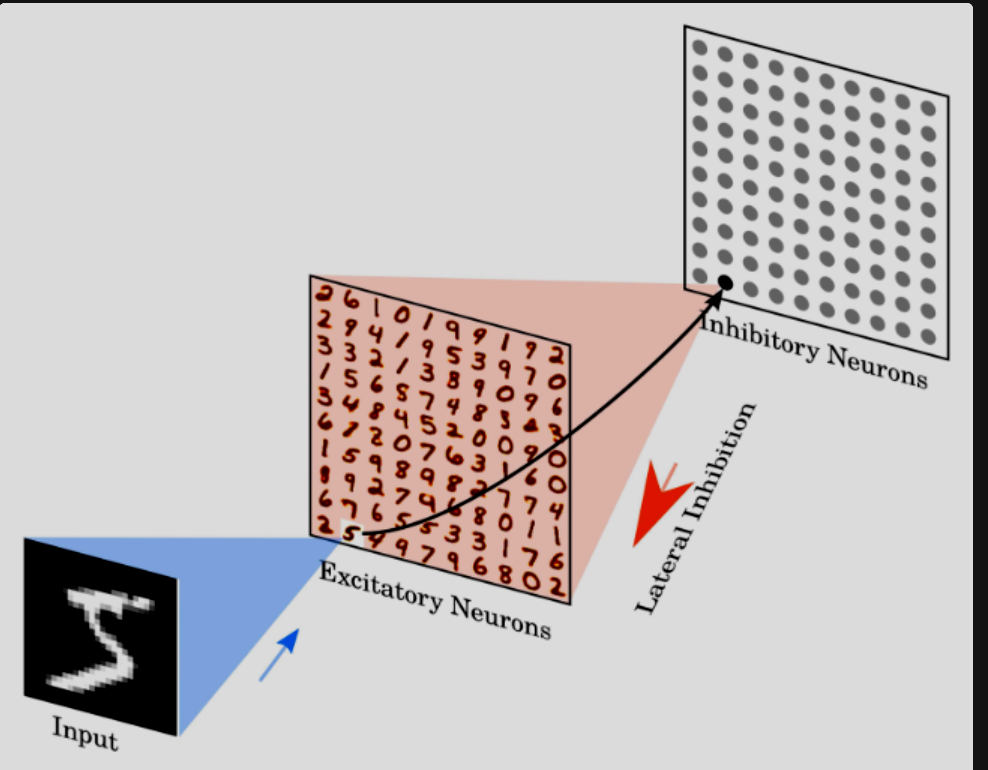